In [1]:
from pathlib import Path
from qcodes import Station
import numpy as np
import matplotlib.pyplot as plt

# all from the rfsoc4x2 package
from rfsoc4x2 import RFSoC, Config, ResonatorSpec, ConstantPulseSpec, RunConfig
from rfsoc4x2.programs import resonator_spectroscopy, tof_calibration

from qcodes.dataset import (load_by_run_spec, load_by_id)
from qcodes.interactive_widget import experiments_widget

In [2]:
IP_ADDRESS = "192.168.2.99"
path2db = Path("database/test.db")

## Calibration and config save

In [3]:
resonator = ResonatorSpec(name='resonator', dac=1, adc=2, frequency=5e9, nqz=2, readout_length=1e-6, time_of_flight=0e-9)
readout_pulse = ConstantPulseSpec(name='readout', element='resonator', detuning=0, phase=0, gain=1, length=0.5e-6)

conf = Config(elements = [resonator], pulses = [readout_pulse])

In [4]:
station = Station()

rfsoc = RFSoC(name="rfsoc", ip=IP_ADDRESS, station=station, db_path=path2db, config=conf)

# tProc type and revision, sample rates, generator types, marker pins
print(rfsoc.qi.soccfg)


Using database at database\test.db.
Creating new QickInstrument with name rfsoc and IP 192.168.2.99.
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4570ce6322434b93ac0e2fccd095ff31@192.168.2.99:45153
Adding QickInstrument rfsoc to the station.
QickInstrument rfsoc added to the station.
Applying configuration to QickInstrument rfsoc.
  element resonator (resonator) on DAC 1
  pulse readout (ConstantPulseSpec) on resonator
Configuration applied to QickInstrument rfsoc.
QICK running on RFSoC4x2, software version 0.2.418

Firmware configuration (built Tue Dec  9 20:12:40 2025):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 491.520
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B


decimated buffer : 16384 samples
window           : 1000 ns -> 553 samples (1.81 ns each)
averaging        : 29 hardware x 10 software
estimated time   : 0.1 s
Running autocalibration for resonator at 5000000000.0 Hz.
Running autocalibrate_tof_resonator (decimated).
Starting experimental run with id: 14. 


  0%|          | 0/10 [00:00<?, ?it/s]

Stored as run 14.
arrival 298.95 ns + margin 5.00 ns = 303.95 ns (was 0.00 ns)
Updating resonator: time_of_flight from 0.0 to 3.039527190934047e-07
Applied updated spec for resonator to hardware.
Resonator resonator spec updated with time-of-flight delay: 303.95 ns


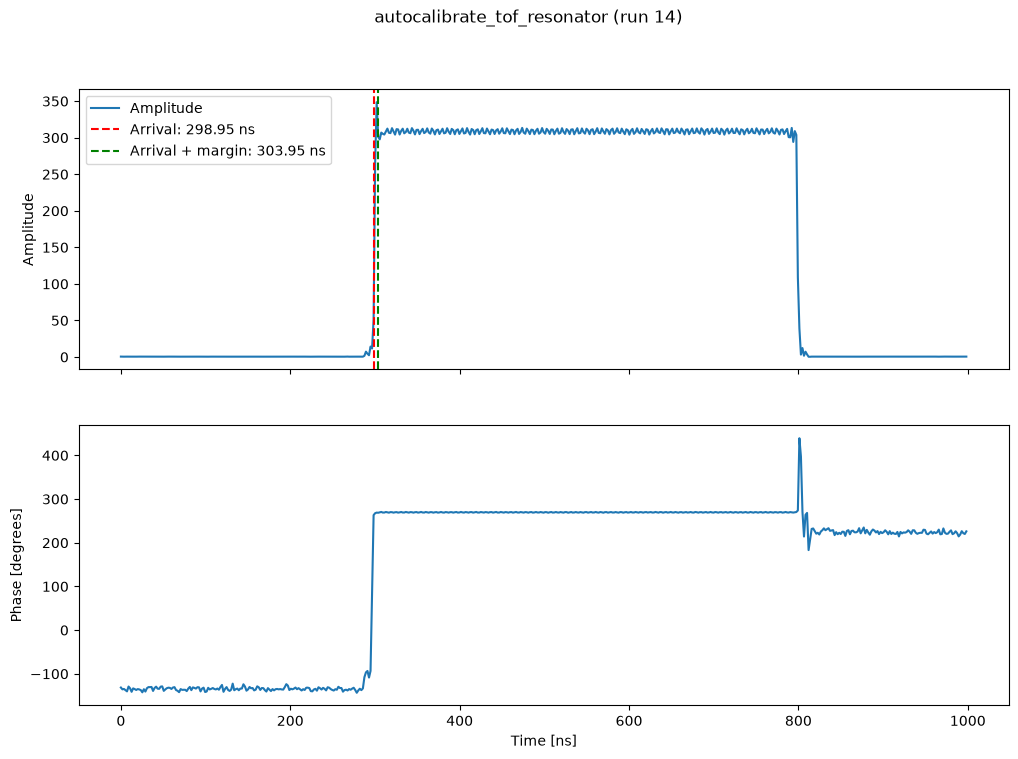

In [5]:
tof, run_id = tof_calibration(
    rfsoc=rfsoc,
    resonator=rfsoc.element("resonator"),
    pulse_length=readout_pulse.length,
    window=1e-6,
    margin=5e-9,
    smooth=7,
    min_snr=10,
    soft_avg=10,
    verbose=True,
    plot=True
)

In [7]:
calib_path = Path("calibration/tof_calibration_29-9-26.json")
config_path = Path("calibration/config_29-9-26.json")

rfsoc.save_calibration(calib_path)
rfsoc.config.save(config_path)

Saved calibration to calibration\tof_calibration_29-9-26.json.
Saved setup to calibration\config_29-9-26.json.


WindowsPath('calibration/config_29-9-26.json')

In [8]:
rfsoc.close()

Closing QickInstrument rfsoc.
QickInstrument rfsoc closed.
QickInstrument rfsoc removed from the station.


## Resonator spectroscopy

In [3]:
config_path = Path("calibration/config_29-9-26.json")

conf = Config.load(config_path)

station = Station()
rfsoc = RFSoC(name="rfsoc", ip=IP_ADDRESS, station=station, db_path=path2db, config=conf)

print(rfsoc.qi.soccfg)

Using database at database\test.db.
Creating new QickInstrument with name rfsoc and IP 192.168.2.99.
Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_4570ce6322434b93ac0e2fccd095ff31@192.168.2.99:45153
Adding QickInstrument rfsoc to the station.
QickInstrument rfsoc added to the station.
Applying configuration to QickInstrument rfsoc.
  element resonator (resonator) on DAC 1
  pulse readout (ConstantPulseSpec) on resonator
Configuration applied to QickInstrument rfsoc.
QICK running on RFSoC4x2, software version 0.2.418

Firmware configuration (built Tue Dec  9 20:12:40 2025):

	Global clocks (MHz): tProc dispatcher timing 614.400, RF reference 491.520
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 0, DAC tile 2], [ADC tile 0, ADC tile 2]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B


In [4]:
f_start = 5e9
f_stop = 8e9
f_points = 1000

resonator        : resonator (DAC 1, ADC 2)
span             : 5.000000 - 8.000000 GHz, 1000 points (3003.0 kHz step)
readout pulse    : 500 ns, gain 1
readout window   : 1000 ns -> ~1000 kHz resolution
averaging        : 1000 hardware x 1 software
uploads          : 1000
estimated time   : 1.8 min
Running spectroscopy_resonator_5.0000e+09_8.0000e+09 (accumulated).
Starting experimental run with id: 18. 


  0%|          | 0/1000 [00:00<?, ?it/s]

Stored as run 18.
stored as run    : 18


C:\Users\quantum\Documents\QCT\drivers\RFSoC4x2_driver\src\rfsoc4x2\programs\resonator_spectroscopy.py:134: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


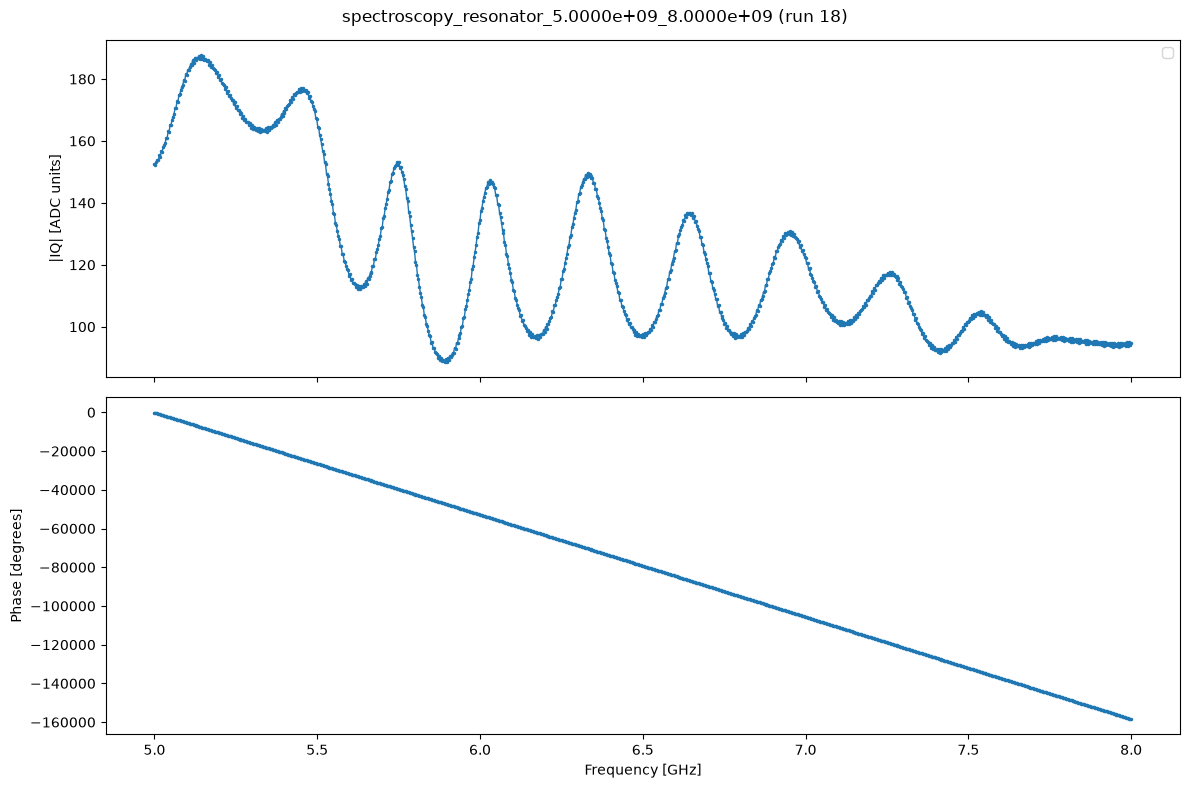

In [5]:
freq, iq = resonator_spectroscopy(
    rfsoc=rfsoc,
    resonator=rfsoc.element("resonator"),
    f_start=f_start,
    f_stop=f_stop,
    f_points=f_points)